# 01 — Data Collection and Quality Assurance

## Inflation Prediction and Economic Signal Analysis: A Multi-Country Time-Series Study

**Phase 1 Deliverable** · **Fully Automated Pipeline (v2 with multi-source fallback)**

---

## Executive Summary

This notebook executes the **complete data-collection pipeline** for a multi-country inflation forecasting framework covering five economies (USA, Japan, United Kingdom, Germany, and China) from 2000-01 to the latest available observation. Five canonical macroeconomic indicators — CPI, policy interest rate, unemployment rate, GDP, and broad money supply — are retrieved per country, yielding 25 time series with approximately 6,000 observations.

**Pipeline stages (executed automatically in this notebook):**

1. **Phase 1 v1** — FRED API retrieval of all 25 series using canonical Series IDs
2. **Phase 2 diagnostic** — systematic staleness and structural-gap assessment
3. **Phase 1 v2** — strategic replacement of six series identified as critically stale:
   - Four replaced with fresh FRED alternatives (including two manual economic-semantics overrides)
   - One replaced via manual download from the Japan Statistics Bureau (`zmi2020s.csv`)
   - One (China M2) accepted as supplementary per the project's China-data caveat

**Prerequisites (before running this notebook):**

| # | Requirement | Where |
|---|---|---|
| 1 | `FRED_API_KEY=...` set in `.env` at the project root | register free at https://fred.stlouisfed.org/docs/api/api_key.html |
| 2 | Python dependencies installed | `pip install -r requirements.txt` |
| 3 | `zmi2020s.csv` placed at `data/raw/_manual/zmi2020s.csv` | download from [stat.go.jp](https://www.stat.go.jp/data/cpi/) → 長期時系列データ → 中分類指数 (Japan CPI, 2020=100, nationwide, monthly) |

After satisfying prerequisites, running this notebook top-to-bottom ("Run All") will produce the complete, validated dataset in `data/raw/`.

---

## Notebook Structure

| § | Section | Output |
|---|---|---|
| 1 | Theoretical Framework | — |
| 2 | Country Selection | — |
| 3 | Multi-Source Data Architecture | — |
| 4 | Environment Setup and Prerequisites | Verified FRED client + manual file |
| 5 | Phase 1 v1 — FRED Collection | 25 CSVs in `data/raw/` |
| 6 | Phase 2 Diagnostic | Staleness table, narrative-risk assessment |
| 7 | Phase 1 v2 — Strategic Rebuild | 4 FRED replacements + audit log |
| 8 | Phase 1 v2 — Japan CPI Manual Import | Updated `JAPAN_CPI.csv` |
| 9 | Final Verification | Post-rebuild diagnostic |
| 10 | Visualisation | Staleness bar, CPI comparison, Japan v1-vs-v2 |
| 11 | Data Integrity and Limitations | — |
| 12 | Decision Log and Next Steps | — |

---

## 1. Theoretical Framework

The five indicators collected per country each represent a distinct transmission channel through which economic conditions influence inflation.

| Indicator | Theoretical role | School / reference |
|---|---|---|
| **CPI (Consumer Price Index)** | Target variable | Laspeyres (1871); OECD harmonisation |
| **Policy interest rate** | Primary monetary tool | Taylor (1993); Friedman (1968) |
| **Unemployment rate** | Labour-market slack | Phillips (1958); Samuelson & Solow (1960) |
| **GDP (real)** | Aggregate demand / output gap | Keynesian demand-pull |
| **Broad money supply (M2/M3)** | Monetarist transmission | Friedman (1956) Quantity Theory |

### Three Named Narratives

The project is organised around three testable narratives:

- **N1 — Phillips Curve**: Does lower unemployment still predict higher inflation?
- **N2 — Monetary Policy Lag**: How many months after a rate change does inflation respond?
- **N3 — Japan's Uniqueness**: Why 30 years of deflation, and why did the pattern reverse in 2022?

N3 imposes the strictest data requirement: Japanese series must extend past the 2022 energy-shock inflation reversal. This constraint drives the Japan-CPI portion of the Phase 1 v2 rebuild (§8).

---

## 2. Country Selection

### Main analysis (4 countries)

| Country | Role |
|---|---|
| 🇺🇸 USA | Benchmark — richest data availability; global reference |
| 🇯🇵 Japan | Structural contrast — deflation era + 2022 reversal |
| 🇬🇧 UK | Post-Brexit structural change; independent BOE policy |
| 🇩🇪 Germany | Euro-area proxy; energy-shock exposure |

### Supplementary (1 country)

| Country | Handling |
|---|---|
| 🇨🇳 China | Included with explicit data-reliability caveat |

**China caveat (D-001 in ProjectDriven.md):** Official Chinese macroeconomic data carries documented reliability concerns: GDP figures align consistently with government targets; the CPI basket composition is opaque; unemployment statistics exclude rural and migrant workers (300M+ people). China is therefore **excluded from the main VAR models** and included only as a supplementary descriptive comparison.

---

## 3. Multi-Source Data Architecture

A single-source strategy is fragile — one maintainer's update cadence gates the entire project. This project therefore implements a three-tier source hierarchy with each tier invoked only when the tier above is insufficient.

```
TIER 1 — PRIMARY: FRED API (fredapi)
   ↓ (if FRED series stale or missing)
TIER 2 — SECONDARY: FRED alternative Series IDs (scout-tested)
   ↓ (if no FRED alternative fresh enough)
TIER 3 — TERTIARY: Direct from primary statistical agency
           (here: Japan Statistics Bureau long-term CSV)
```

**China unemployment** is a special case: the World Bank API is used (annual data only, supplementary reference).

This architecture emerged empirically from the Phase 2 diagnostic rather than being designed *a priori*. The complete derivation is visible in the pipeline below.

---

## 4. Environment Setup and Prerequisites

### 4.1 Imports and Path Resolution

In [29]:
import os
import re
import sys
import time
import shutil
from pathlib import Path
from datetime import datetime
from itertools import groupby

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests

try:
    from dotenv import load_dotenv
except ImportError:
    raise ImportError("Install python-dotenv: pip install python-dotenv")
try:
    from fredapi import Fred
except ImportError:
    raise ImportError("Install fredapi: pip install fredapi")

# Visualisation settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
pd.set_option('display.max_rows', 40)
pd.set_option('display.width', 160)

# Resolve project root by walking up from cwd until we find data/ and .env
def find_project_root():
    cur = Path.cwd().resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate 'data/' from cwd={Path.cwd()}. "
        "Run this notebook from within the project tree."
    )

PROJECT_ROOT = find_project_root()
DATA_RAW        = PROJECT_ROOT / 'data' / 'raw'
DATA_MANUAL     = DATA_RAW / '_manual'
DATA_DOC        = PROJECT_ROOT / 'data' / 'documentation'
FIG_DIR         = PROJECT_ROOT / 'outputs' / 'figures'

# Ensure directories
for d in [DATA_RAW, DATA_MANUAL, DATA_DOC, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
ARCHIVE_DIR   = DATA_RAW / '_archive_v1' / RUN_TIMESTAMP

print(f"CWD          : {Path.cwd()}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data dir : {DATA_RAW}")
print(f"Run timestamp: {RUN_TIMESTAMP}")

CWD          : c:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis\notebooks
Project root : C:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis
Raw data dir : C:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis\data\raw
Run timestamp: 20260417_163520


### 4.2 Prerequisite Verification

Before executing any pipeline stages, we verify that (a) FRED API credentials are available, and (b) the manually-downloaded Japan CPI file has been placed in the expected location. Either absence terminates the notebook with a clear error message.

In [30]:
# (a) FRED_API_KEY
env_path = PROJECT_ROOT / '.env'
if env_path.exists():
    load_dotenv(env_path)
FRED_API_KEY = os.getenv('FRED_API_KEY')

if not FRED_API_KEY:
    raise RuntimeError(
        f"FRED_API_KEY not found.\n"
        f"  Expected in: {env_path}\n"
        f"  Get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html\n"
        f"  Then add the line: FRED_API_KEY=your_key_here"
    )

FRED = Fred(api_key=FRED_API_KEY)
print(f"✓ FRED API client initialised")

# (b) Manual Japan CPI file
MANUAL_CPI = DATA_MANUAL / 'zmi2020s.csv'
if not MANUAL_CPI.exists():
    raise RuntimeError(
        f"Required manual file missing: {MANUAL_CPI}\n\n"
        f"  Japan CPI from all FRED/OECD-harmonised series stopped updating in 2021-06.\n"
        f"  Download the current series directly from the Japan Statistics Bureau:\n\n"
        f"    1. Visit https://www.stat.go.jp/data/cpi/\n"
        f"    2. Navigate to '長期時系列データ' > '品目別価格指数' > '全国' > '月次'\n"
        f"    3. Download '中分類指数 (1970年1月〜最新月)' as CSV\n"
        f"    4. Save to: {MANUAL_CPI}\n"
    )
print(f"✓ Manual Japan CPI file found: {MANUAL_CPI.name} "
      f"({MANUAL_CPI.stat().st_size:,} bytes)")

✓ FRED API client initialised
✓ Manual Japan CPI file found: zmi2020s.csv (284,181 bytes)


## 5. Phase 1 v1 — Initial FRED Collection

### 5.1 Canonical Series Specification (v1)

The Phase 1 v1 specification uses FRED Series IDs chosen for their coverage of 2000-present and their conformance to the theoretical framework above. Six of these series will later be identified as critically stale by the Phase 2 diagnostic; they are retrieved here first so the diagnostic narrative plays out as it did in practice.

In [31]:
# Phase 1 v1 — canonical FRED Series IDs (pre-rebuild state)
INDICATORS_V1 = {
    'USA': {
        'CPI':          'CPIAUCSL',         # Consumer Price Index, SA
        'POLICY_RATE':  'FEDFUNDS',         # Federal Funds Rate, effective
        'UNEMPLOYMENT': 'UNRATE',           # Civilian unemployment rate
        'GDP':          'GDP',              # Gross Domestic Product (quarterly)
        'M2':           'M2SL',             # M2 Money Stock, level
    },
    'JAPAN': {
        'CPI':          'JPNCPIALLMINMEI',  # (will be stale → v2 manual replacement)
        'POLICY_RATE':  'IRSTCB01JPM156N',  # (will be stale → v2 replacement)
        'UNEMPLOYMENT': 'LRUNTTTTJPM156S',  # Harmonised unemployment 15-64
        'GDP':          'JPNRGDPEXP',       # Real GDP, expenditure (quarterly)
        'M2':           'MYAGM2JPM189S',    # (will be stale → v2 replacement)
    },
    'UK': {
        'CPI':          'GBRCPIALLMINMEI',  # OECD harmonised CPI
        'POLICY_RATE':  'IRSTCI01GBM156N',  # Immediate interest rate (BOE)
        'UNEMPLOYMENT': 'LRHUTTTTGBM156S',  # Harmonised unemployment (extended)
        'GDP':          'NAEXKP01GBQ652S',  # (will be stale → v2 replacement)
        'M2':           'MANMM101GBM189S',  # (will be stale → v2 replacement)
    },
    'GERMANY': {
        'CPI':          'DEUCPIALLMINMEI',  # OECD harmonised CPI
        'POLICY_RATE':  'IRSTCI01DEM156N',  # Immediate interest rate (ECB transmission)
        'UNEMPLOYMENT': 'LRHUTTTTDEM156S',  # Harmonised unemployment
        'GDP':          'CPMNACSCAB1GQDE',  # Real GDP, chain-linked (quarterly)
        'M2':           'M2SL',             # Proxy using USA M2 (Germany-specific scout pending)
    },
    'CHINA': {
        'CPI':          'CHNCPIALLMINMEI',  # OECD harmonised (acceptable)
        'POLICY_RATE':  'INTDSRCNM193N',    # PBOC discount rate
        'UNEMPLOYMENT': 'WB_ANNUAL',        # World Bank annual (not FRED)
        'GDP':          'CHNGDPNQDSMEI',    # Nominal GDP (quarterly)
        'M2':           'MANMM101CNM189S',  # (will be stale, supplementary-acceptable)
    },
}

total_series = sum(len(v) for v in INDICATORS_V1.items() for k in [1])
total_series = sum(len(v) for v in INDICATORS_V1.values())
print(f"v1 specification: {total_series} series across {len(INDICATORS_V1)} countries")

v1 specification: 25 series across 5 countries


### 5.2 Execute v1 Collection

Each series is retrieved from FRED (with World Bank fallback for China unemployment) and saved to `data/raw/{COUNTRY}_{INDICATOR}.csv` in the standard single-column format with `date` index.

**Robustness features:**
- Each API call is wrapped in a retry loop with exponential backoff (1s → 2s → 4s) on transient failures (timeouts, connection errors, 5xx HTTP errors)
- Permanent failures (invalid series IDs, 4xx errors) abort immediately without wasted retries
- Individual series failures are logged but do not halt the loop — downstream diagnostic will surface them as `MISSING`
- Network-resilient timeouts: 45s for FRED, 60s for World Bank (the latter is known to be slower)

In [32]:
# Low-level fetchers with retry logic
#
# Retry policy:
#   - Up to 3 attempts per series
#   - Exponential backoff: 1s, 2s, 4s between retries
#   - Only retries on transient failures (timeouts, connection errors)
#   - Permanent failures (invalid series ID, 404) abort immediately
# This hardens the pipeline against the World Bank / FRED API latency spikes
# that were observed in earlier runs.

MAX_FETCH_ATTEMPTS = 3
FRED_TIMEOUT = 45
WB_TIMEOUT   = 60

def _backoff_delay(attempt):
    return 2 ** (attempt - 1)  # 1, 2, 4 seconds


def fetch_from_fred(series_id, start='2000-01-01'):
    last_err = None
    for attempt in range(1, MAX_FETCH_ATTEMPTS + 1):
        try:
            s = FRED.get_series(series_id, observation_start=start)
            if s is None or s.empty:
                return None, 'empty response from FRED'
            return s, None
        except Exception as e:
            # fredapi raises various wrappers; inspect message for transient hints
            err_str = str(e)[:150]
            is_transient = any(hint in err_str.lower() for hint in
                               ('timeout', 'timed out', 'connection',
                                'temporarily', 'gateway', '502', '503', '504'))
            last_err = f"attempt {attempt}/{MAX_FETCH_ATTEMPTS}: {err_str}"
            if is_transient and attempt < MAX_FETCH_ATTEMPTS:
                delay = _backoff_delay(attempt)
                print(f" [retry in {delay}s]", end='', flush=True)
                time.sleep(delay)
                continue
            return None, last_err
    return None, last_err


def fetch_china_unemployment_worldbank():
    url = ('http://api.worldbank.org/v2/country/CHN/'
           'indicator/SL.UEM.TOTL.ZS?format=json&per_page=100&date=2000:2030')
    last_err = None
    for attempt in range(1, MAX_FETCH_ATTEMPTS + 1):
        try:
            r = requests.get(url, timeout=WB_TIMEOUT)
            r.raise_for_status()
            payload = r.json()
            if not isinstance(payload, list) or len(payload) < 2:
                return None, 'unexpected World Bank payload shape'
            obs = payload[1]
            rows = []
            for o in obs:
                date_str = o.get('date')
                val = o.get('value')
                if date_str and val is not None:
                    try:
                        rows.append((pd.Timestamp(year=int(date_str), month=12, day=1),
                                     float(val)))
                    except (ValueError, TypeError):
                        continue
            if not rows:
                return None, 'no valid observations in World Bank response'
            return pd.Series(dict(rows)).sort_index(), None
        except (requests.Timeout, requests.ConnectionError) as e:
            last_err = (f"attempt {attempt}/{MAX_FETCH_ATTEMPTS} "
                        f"[{type(e).__name__}]: {str(e)[:100]}")
            if attempt < MAX_FETCH_ATTEMPTS:
                delay = _backoff_delay(attempt)
                print(f" [retry in {delay}s]", end='', flush=True)
                time.sleep(delay)
                continue
            return None, last_err
        except requests.HTTPError as e:
            # 4xx / 5xx: retry only on 5xx
            status = e.response.status_code if e.response else None
            if status and 500 <= status < 600 and attempt < MAX_FETCH_ATTEMPTS:
                last_err = f"attempt {attempt}/{MAX_FETCH_ATTEMPTS}: HTTP {status}"
                delay = _backoff_delay(attempt)
                print(f" [retry in {delay}s]", end='', flush=True)
                time.sleep(delay)
                continue
            return None, f"HTTP {status}: {str(e)[:100]}"
        except Exception as e:
            return None, f"non-retryable: {type(e).__name__}: {str(e)[:100]}"
    return None, last_err


def save_series(country, indicator, series):
    col = f"{country}_{indicator}"
    df = series.to_frame(name=col)
    df.index.name = 'date'
    df.to_csv(DATA_RAW / f"{country}_{indicator}.csv")

# Execute v1 collection
v1_log = []
print(f"Collecting v1 series (~25 API calls, ~10-30 seconds with retries)...\n")
for country, inds in INDICATORS_V1.items():
    for indicator, sid in inds.items():
        label = f"{country}_{indicator}"
        print(f"  {label:25s} <- {sid:22s} ", end='', flush=True)
        if sid == 'WB_ANNUAL':
            s, err = fetch_china_unemployment_worldbank()
            source = 'WorldBank'
        else:
            s, err = fetch_from_fred(sid)
            source = 'FRED'
        if s is None:
            print(f" FAILED ({err})")
            v1_log.append({'country': country, 'indicator': indicator,
                           'series_id': sid, 'source': source,
                           'status': 'FAILED', 'n_obs': 0, 'error': err})
        else:
            save_series(country, indicator, s)
            non_na = s.dropna()
            eff_end = non_na.index.max().strftime('%Y-%m') if not non_na.empty else '?'
            print(f" OK   n={len(s):>4}  end={eff_end}")
            v1_log.append({'country': country, 'indicator': indicator,
                           'series_id': sid, 'source': source,
                           'status': 'OK', 'n_obs': len(s),
                           'effective_end': eff_end, 'error': None})
        time.sleep(0.15)

V1_LOG = pd.DataFrame(v1_log)
n_ok = (V1_LOG['status'] == 'OK').sum()
n_fail = (V1_LOG['status'] == 'FAILED').sum()
print(f"\nv1 collection complete: {n_ok} OK, {n_fail} failed")
if n_fail > 0:
    print("\nFailed series (will be shown as MISSING in diagnostic):")
    for _, r in V1_LOG[V1_LOG['status']=='FAILED'].iterrows():
        print(f"  {r['country']}_{r['indicator']}: {r['error']}")


  USA_CPI                   <- CPIAUCSL                OK   n= 315  end=2026-03
  USA_POLICY_RATE           <- FEDFUNDS                OK   n= 315  end=2026-03
  USA_UNEMPLOYMENT          <- UNRATE                  OK   n= 315  end=2026-03
  USA_GDP                   <- GDP                     OK   n= 104  end=2025-10
  USA_M2                    <- M2SL                    OK   n= 314  end=2026-02
  JAPAN_CPI                 <- JPNCPIALLMINMEI         OK   n= 268  end=2021-06
  JAPAN_POLICY_RATE         <- IRSTCB01JPM156N         OK   n= 288  end=2023-12
  JAPAN_UNEMPLOYMENT        <- LRUNTTTTJPM156S         OK   n= 314  end=2026-02
  JAPAN_GDP                 <- JPNRGDPEXP              OK   n= 104  end=2025-10
  JAPAN_M2                  <- MYAGM2JPM189S           OK   n= 206  end=2017-02
  UK_CPI                    <- GBRCPIALLMINMEI         OK   n= 303  end=2025-03
  UK_POLICY_RATE            <- IRSTCI01GBM156N         OK   n= 315  end=2026-03
  UK_UNEMPLOYMENT           <- LRHUTTTT

## 6. Phase 2 Diagnostic — Discovery of Hidden Staleness

Claiming '100% coverage' after v1 would be premature. A systematic diagnostic computes the *effective* date range of each series (accounting for trailing NaN padding), classifies any gaps, and assesses freshness against today.

### 6.1 Staleness Thresholds

| Status | Definition | Interpretation |
|---|---|---|
| 🟢 FRESH | < 6 months outdated | Within normal publication cadence |
| 🟡 WARNING | 6–24 months outdated | Noticeable lag |
| 🔴 CRITICAL | > 24 months outdated | Broken for recent analysis |

In [33]:
# Loader + diagnostic functions (used for v1 now, re-used for v2 verification later)
def load_series(country, indicator):
    fpath = DATA_RAW / f"{country}_{indicator}.csv"
    if not fpath.exists():
        return None, f"file not found"
    try:
        df = pd.read_csv(fpath)
    except Exception as e:
        return None, f"read_csv failed: {str(e)[:80]}"
    if df.empty or df.shape[1] < 2:
        return None, f"empty"
    date_col = next((c for c in df.columns
                     if c.lower() in ('date', 'datetime', 'observation_date')),
                    df.columns[0])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col]).set_index(date_col).sort_index()
    if df.empty:
        return None, "no valid dates"
    return df[df.columns[0]].rename(df.columns[0]), None


def classify_na_runs(s):
    if s.empty or not s.isna().any():
        return []
    isna = s.isna().values
    runs = []
    in_run, run_start = False, None
    for i, v in enumerate(isna):
        if v and not in_run:
            in_run, run_start = True, i
        elif not v and in_run:
            runs.append((run_start, i - 1))
            in_run = False
    if in_run:
        runs.append((run_start, len(isna) - 1))
    out = []
    for start_i, end_i in runs:
        if start_i == 0:              gap_type = 'leading'
        elif end_i == len(isna) - 1:  gap_type = 'trailing'
        else:                         gap_type = 'internal'
        out.append({'start': s.index[start_i], 'end': s.index[end_i],
                    'length': end_i - start_i + 1, 'gap_type': gap_type})
    return out


def months_between(a, b):
    return (b.year - a.year) * 12 + (b.month - a.month)


def diagnose_all(indicators_dict):
    today = pd.Timestamp.today().normalize().replace(day=1)
    rows = []
    for country, inds in indicators_dict.items():
        for indicator in inds:
            s, err = load_series(country, indicator)
            if s is None:
                rows.append({'country': country, 'indicator': indicator,
                             'status': f'LOAD FAILED: {err}',
                             'effective_end': None, 'months_outdated': np.nan,
                             'freshness': 'MISSING', 'n_obs': 0,
                             'max_internal_gap': 0, 'trailing_na': 0})
                continue
            non_na = s.dropna()
            if non_na.empty:
                rows.append({'country': country, 'indicator': indicator,
                             'status': 'ALL NaN',
                             'effective_end': None, 'months_outdated': np.nan,
                             'freshness': 'MISSING', 'n_obs': len(s),
                             'max_internal_gap': 0, 'trailing_na': 0})
                continue
            runs = classify_na_runs(s)
            internal = [r for r in runs if r['gap_type'] == 'internal']
            trailing = [r for r in runs if r['gap_type'] == 'trailing']
            eff_end = non_na.index.max()
            stale = months_between(eff_end, today)
            freshness = ('FRESH'    if stale < 6  else
                         'WARNING'  if stale < 24 else
                         'CRITICAL')
            rows.append({
                'country':          country,
                'indicator':        indicator,
                'status':           'OK',
                'effective_start':  non_na.index.min().strftime('%Y-%m'),
                'effective_end':    eff_end.strftime('%Y-%m'),
                'months_outdated':  stale,
                'freshness':        freshness,
                'n_obs':            len(s),
                'max_internal_gap': max((r['length'] for r in internal), default=0),
                'trailing_na':      sum(r['length'] for r in trailing),
            })
    return pd.DataFrame(rows)


# Diagnose the v1 state
DIAGNOSTIC_V1 = diagnose_all(INDICATORS_V1)
print("Phase 2 diagnostic on v1 state:\n")
print(DIAGNOSTIC_V1[['country', 'indicator', 'effective_end',
                     'months_outdated', 'freshness', 'trailing_na']]
      .to_string(index=False))

Phase 2 diagnostic on v1 state:

country    indicator effective_end  months_outdated freshness  trailing_na
    USA          CPI       2026-03                1     FRESH            0
    USA  POLICY_RATE       2026-03                1     FRESH            0
    USA UNEMPLOYMENT       2026-03                1     FRESH            0
    USA          GDP       2025-10                6   WARNING            0
    USA           M2       2026-02                2     FRESH            0
  JAPAN          CPI       2021-06               58  CRITICAL           10
  JAPAN  POLICY_RATE       2023-12               28  CRITICAL            0
  JAPAN UNEMPLOYMENT       2026-02                2     FRESH            0
  JAPAN          GDP       2025-10                6   WARNING            0
  JAPAN           M2       2017-02              110  CRITICAL            0
     UK          CPI       2025-03               13   WARNING            0
     UK  POLICY_RATE       2026-03                1     FRESH      

### 6.2 Discovery — The Six Stale Series

The diagnostic reveals that while all 25 series were successfully downloaded, six are materially stale (>24 months outdated). Notably, one of them — Japan CPI from the FRED/OECD pipeline — ends in June 2021 with ten months of trailing NaN padding. This is not visible from a naive file-existence check; it requires effective-end analysis.

In [34]:
# Isolate the stale series
STALE = DIAGNOSTIC_V1[DIAGNOSTIC_V1['freshness'] == 'CRITICAL'].copy()
print("Series with CRITICAL staleness (requiring Phase 1 v2 action):\n")
print(STALE[['country', 'indicator', 'effective_end',
             'months_outdated', 'trailing_na']].to_string(index=False))
print(f"\n{len(STALE)} of {len(DIAGNOSTIC_V1)} series classified CRITICAL.")

Series with CRITICAL staleness (requiring Phase 1 v2 action):

country   indicator effective_end  months_outdated  trailing_na
  JAPAN         CPI       2021-06               58           10
  JAPAN POLICY_RATE       2023-12               28            0
  JAPAN          M2       2017-02              110            0
     UK         GDP       2023-07               33            0
     UK          M2       2023-11               29            0
  CHINA         GDP       2023-07               33            0
  CHINA          M2       2018-12               88            0

7 of 25 series classified CRITICAL.


**Implication for the three narratives:**

| Narrative | Impact of staleness |
|---|---|
| N1 — Phillips Curve | Japan-specific portion would truncate at 2021-06 |
| N2 — Monetary Policy Lag | Japan Policy Rate and M2 unavailable for 2020+ test window |
| **N3 — Japan's Uniqueness** | **Invalidated — 2022 inflation reversal entirely outside data** |

Since N3 is the project's signature narrative for Japan-focused employers (per ProjectScope §17), the rebuild is not optional. Four strategies were considered (A: full rebuild, B: truncate all to earliest end, C: country-specific periods, **D: targeted multi-source replacement**). Strategy D was adopted.

---

## 7. Phase 1 v2 — Strategic FRED Replacements

### 7.1 Replacement Specification

Four of the six stale series can be replaced with fresh FRED alternatives. A candidate scout (documented separately in `phase1v2_candidate_scout.py`) tested 31 alternative FRED Series IDs and identified winners. Two of the scout's raw winners were subsequently overridden for economic-semantics reasons:

- **Japan Policy Rate** — scout's winner `IRLTLT01JPM156N` is the 10-year JGB yield (a market rate, not a BOJ operational target). Overridden to `IRSTCI01JPM156N` (immediate call money rate), which IS the BOJ operational target and correctly supports narrative N2.
- **UK GDP** — scout's winner `UKNGDP` is nominal GDP. Cross-country VAR with USA/Japan/Germany (all real) requires UK to match. Overridden to `NGDPRSAXDCGBQ` (Real GDP SA); identical freshness.

### 7.2 Unit Harmonisation

The replacement M2 series for Japan and UK are YoY growth rates rather than levels (the only fresh FRED candidates). USA and Germany M2 remain in level form. This heterogeneity is harmonised in Phase 2 cleaning by computing YoY growth for USA/Germany — a treatment that is theoretically preferable anyway (the Quantity Theory relates money *growth* to inflation, not levels).

In [35]:
# Replacement specification with rationales
REPLACEMENTS = [
    {
        'country':       'JAPAN',
        'indicator':     'M2',
        'old_series_id': 'MYAGM2JPM189S',
        'new_series_id': 'MABMM301JPM657S',
        'new_nature':    'M3 broad money, YoY % growth',
        'manual_override': False,
        'rationale':     'Only FRED candidate with FRESH status. M3 YoY growth supports monetarist channel.',
    },
    {
        'country':       'JAPAN',
        'indicator':     'POLICY_RATE',
        'old_series_id': 'IRSTCB01JPM156N',
        'new_series_id': 'IRSTCI01JPM156N',
        'new_nature':    'Immediate call money rate (BOJ operational target)',
        'manual_override': True,
        'rationale':     'OVERRIDE: scout picked IRLTLT (10-year JGB yield = market rate with expectations, not policy variable). Replaced with IRSTCI (call money), which is BOJ\'s actual operational target.',
    },
    {
        'country':       'UK',
        'indicator':     'M2',
        'old_series_id': 'MANMM101GBM189S',
        'new_series_id': 'MABMM301GBM657S',
        'new_nature':    'M3 broad money, YoY % growth',
        'manual_override': False,
        'rationale':     'Only FRED candidate with FRESH status.',
    },
    {
        'country':       'UK',
        'indicator':     'GDP',
        'old_series_id': 'NAEXKP01GBQ652S',
        'new_series_id': 'NGDPRSAXDCGBQ',
        'new_nature':    'Real GDP, SA, quarterly',
        'manual_override': True,
        'rationale':     'OVERRIDE: scout picked UKNGDP (nominal GDP). Cross-country consistency requires real GDP. Identical freshness to scout winner.',
    },
]

REPLACEMENT_SPEC = pd.DataFrame(REPLACEMENTS)
print(f"{len(REPLACEMENTS)} FRED replacements specified.")
REPLACEMENT_SPEC[['country', 'indicator', 'old_series_id', 'new_series_id',
                  'manual_override']]

4 FRED replacements specified.


,country,indicator,old_series_id,new_series_id,manual_override
0,JAPAN,M2,MYAGM2JPM189S,MABMM301JPM657S,False
1,JAPAN,POLICY_RATE,IRSTCB01JPM156N,IRSTCI01JPM156N,True
2,UK,M2,MANMM101GBM189S,MABMM301GBM657S,False
3,UK,GDP,NAEXKP01GBQ652S,NGDPRSAXDCGBQ,True


### 7.3 Execute Replacements

For each replacement: archive the v1 CSV, fetch the v2 series from FRED, save, and append to the audit log.

In [36]:
# Execute: archive v1, fetch v2, save, log
audit_rows = []
today = pd.Timestamp.today().normalize().replace(day=1)

for r in REPLACEMENTS:
    country, indicator = r['country'], r['indicator']
    label = f"{country}_{indicator}"
    print(f"\n{label}:")

    # Archive v1
    old_path = DATA_RAW / f"{label}.csv"
    if old_path.exists():
        ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(old_path, ARCHIVE_DIR / old_path.name)
        print(f"  Archived: {label}.csv -> _archive_v1/{RUN_TIMESTAMP}/")

    # Fetch v2
    s, err = fetch_from_fred(r['new_series_id'])
    if s is None:
        print(f"  FAILED to fetch {r['new_series_id']}: {err}")
        audit_rows.append({
            'timestamp': RUN_TIMESTAMP, 'country': country, 'indicator': indicator,
            'old_series_id': r['old_series_id'], 'new_series_id': r['new_series_id'],
            'new_nature': r['new_nature'], 'manual_override': r['manual_override'],
            'fetch_status': 'FAILED', 'n_obs': 0, 'effective_end': None,
            'months_outdated': None, 'freshness': None,
            'rationale': r['rationale'], 'error': err,
        })
        continue

    # Save + compute freshness
    save_series(country, indicator, s)
    non_na = s.dropna()
    eff_end = non_na.index.max()
    stale = months_between(eff_end, today)
    freshness = 'FRESH' if stale < 6 else 'WARNING' if stale < 24 else 'CRITICAL'
    print(f"  Wrote:    {label}.csv  n={len(s)}  end={eff_end.strftime('%Y-%m')}  {freshness}")

    audit_rows.append({
        'timestamp': RUN_TIMESTAMP, 'country': country, 'indicator': indicator,
        'old_series_id': r['old_series_id'], 'new_series_id': r['new_series_id'],
        'new_nature': r['new_nature'], 'manual_override': r['manual_override'],
        'fetch_status': 'OK', 'n_obs': len(s),
        'effective_end': eff_end.strftime('%Y-%m'),
        'months_outdated': stale, 'freshness': freshness,
        'rationale': r['rationale'], 'error': None,
    })
    time.sleep(0.15)

# Append to audit log
audit_df_new = pd.DataFrame(audit_rows)
audit_log_path = DATA_DOC / 'phase1v2_rebuild_log.csv'
if audit_log_path.exists():
    audit_df = pd.concat([pd.read_csv(audit_log_path), audit_df_new], ignore_index=True)
else:
    audit_df = audit_df_new
audit_df.to_csv(audit_log_path, index=False)
print(f"\nAudit log updated: {audit_log_path.relative_to(PROJECT_ROOT)}")


JAPAN_M2:
  Archived: JAPAN_M2.csv -> _archive_v1/20260417_163520/
  Wrote:    JAPAN_M2.csv  n=311  end=2025-11  FRESH

JAPAN_POLICY_RATE:
  Archived: JAPAN_POLICY_RATE.csv -> _archive_v1/20260417_163520/
  Wrote:    JAPAN_POLICY_RATE.csv  n=315  end=2026-03  FRESH

UK_M2:
  Archived: UK_M2.csv -> _archive_v1/20260417_163520/
  Wrote:    UK_M2.csv  n=314  end=2026-02  FRESH

UK_GDP:
  Archived: UK_GDP.csv -> _archive_v1/20260417_163520/
  Wrote:    UK_GDP.csv  n=104  end=2025-10  WARNING

Audit log updated: data\documentation\phase1v2_rebuild_log.csv


## 8. Phase 1 v2 — Japan CPI Manual Import

### 8.1 Why Manual

For Japan CPI, the scout tested six OECD-family FRED candidates. **All six stopped updating in June 2021 or earlier** — a structural feature of the OECD harmonisation pipeline for Japan, not a Phase 1 v1 bug. Automated retrieval from IMF IFS was attempted separately and failed (server timeout, then API structure change for DataMapper).

The resolution is direct retrieval from the primary source: the Japan Statistics Bureau (総務省統計局) publishes the 2020-base CPI middle-category index as monthly CSV at [stat.go.jp](https://www.stat.go.jp/data/cpi/). The user downloaded this file manually; this notebook imports it via a dedicated parser.

### 8.2 Robust CSV Parser

The downloaded `zmi2020s.csv` has three characteristics that a naïve CSV loader would fail on:

- **Shift-JIS encoding (cp932)** — not UTF-8
- **Metadata preamble rows** before the actual header
- **Japanese column names and date formats** (`時点`, `総合`, `2000年1月`)

The parser below detects encoding, locates the header row by content matching, and recognises multiple Japanese date formats.

In [37]:
# Robust parser for e-Stat / stat.go.jp CSVs
DATE_COL_HINTS  = ['時点', '年月', '月次', 'date', '日付', 'time', 'period', 'month']
VALUE_COL_HINTS = ['総合', 'all items', 'cpi', 'overall', '指数']

PAT_JP_YM   = re.compile(r'(\d{4})年\s*(\d{1,2})月')
PAT_YM_DASH = re.compile(r'^(\d{4})[\-/](\d{1,2})(?:[\-/]\d{1,2})?$')
PAT_YM_CAT  = re.compile(r'^(\d{4})(\d{2})$')


def detect_csv_header_row(path):
    encodings = ['utf-8-sig', 'cp932', 'utf-8', 'shift_jis', 'cp1252']
    lines = None
    for enc in encodings:
        try:
            with open(path, 'r', encoding=enc) as f:
                tmp = []
                for _ in range(30):
                    ln = f.readline()
                    if not ln: break
                    tmp.append(ln.rstrip('\r\n'))
            lines = tmp
            break
        except UnicodeDecodeError:
            continue
    if not lines:
        return 0
    # Prefer comma-separated row with a DATE hint
    for i, ln in enumerate(lines):
        if ',' not in ln: continue
        low = ln.lower()
        if any(h.lower() in low for h in DATE_COL_HINTS):
            return i
    # Fallback: VALUE hint
    for i, ln in enumerate(lines):
        if ',' not in ln: continue
        low = ln.lower()
        if any(h.lower() in low for h in VALUE_COL_HINTS):
            return i
    return 0


def read_csv_robust(path, header_row):
    encodings = ['utf-8-sig', 'cp932', 'utf-8', 'shift_jis', 'cp1252']
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc, dtype=str,
                             engine='python', on_bad_lines='skip',
                             header=0, skiprows=header_row)
            if not df.empty and df.shape[1] > 0:
                return df, enc
        except Exception:
            continue
    raise ValueError(f"Could not read {path.name} with any encoding")


def parse_date_cell(s):
    if s is None: return None
    s = str(s).strip()
    for pat in [PAT_JP_YM, PAT_YM_DASH]:
        m = pat.match(s)
        if m:
            return pd.Timestamp(int(m.group(1)), int(m.group(2)), 1)
    m = PAT_YM_CAT.match(s)
    if m:
        y, mo = int(m.group(1)), int(m.group(2))
        if 1 <= mo <= 12:
            return pd.Timestamp(y, mo, 1)
    try:
        return pd.to_datetime(s)
    except (ValueError, TypeError):
        return None


def find_col(cols, hints):
    for hint in hints:
        for c in cols:
            if str(c).strip().lower() == hint.lower():
                return c
    for hint in hints:
        for c in cols:
            if hint.lower() in str(c).lower():
                return c
    return None


def load_manual_cpi(path):
    hdr = detect_csv_header_row(path)
    df, enc = read_csv_robust(path, hdr)
    date_col  = find_col(list(df.columns), DATE_COL_HINTS) or df.columns[0]
    value_col = find_col(list(df.columns), VALUE_COL_HINTS)
    if value_col is None:
        # Fallback: first numeric column that isn't the date
        for c in df.columns:
            if c == date_col: continue
            try:
                s_num = pd.to_numeric(df[c].astype(str).str.replace(',', '').str.strip(),
                                      errors='raise')
                if s_num.notna().sum() > 10:
                    value_col = c; break
            except (ValueError, TypeError):
                continue
    if value_col is None:
        raise ValueError(f"No numeric value column found. Columns: {list(df.columns)}")

    rows = []
    for _, r in df.iterrows():
        dt = parse_date_cell(r[date_col])
        if dt is None: continue
        val_str = str(r[value_col]).replace(',', '').strip()
        if val_str in ('', 'nan', 'None', '-', '...'): continue
        try:
            rows.append((dt, float(val_str)))
        except ValueError:
            continue
    if not rows:
        raise ValueError("No valid (date, value) rows parsed")
    s = pd.Series(dict(rows)).sort_index()
    s = s[s.index >= pd.Timestamp('2000-01-01')]
    return s, {'encoding': enc, 'header_row': hdr,
               'date_col': date_col, 'value_col': value_col}


print("Parser functions defined.")

Parser functions defined.


### 8.3 Execute Import

In [38]:
# Archive v1 Japan CPI
old_jpn_path = DATA_RAW / 'JAPAN_CPI.csv'
if old_jpn_path.exists():
    ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copy2(old_jpn_path, ARCHIVE_DIR / 'JAPAN_CPI.csv')
    print(f"Archived v1 JAPAN_CPI.csv -> _archive_v1/{RUN_TIMESTAMP}/")

# Import from manual CSV
print(f"\nReading {MANUAL_CPI.name}...")
cpi_series, parse_meta = load_manual_cpi(MANUAL_CPI)
print(f"  Encoding detected: {parse_meta['encoding']}")
print(f"  Header row       : {parse_meta['header_row']}")
print(f"  Columns used     : date='{parse_meta['date_col']}', value='{parse_meta['value_col']}'")
print(f"  Observations     : {len(cpi_series)}")
print(f"  Date range       : {cpi_series.index.min().strftime('%Y-%m')} "
      f"-> {cpi_series.index.max().strftime('%Y-%m')}")

# Validate freshness improves on v1
v2_eff_end = cpi_series.dropna().index.max()
v2_stale = months_between(v2_eff_end, today)
if v2_eff_end < pd.Timestamp('2022-01-01'):
    raise RuntimeError(
        f"Manual CPI effective end {v2_eff_end} does not improve on v1 stale point. "
        "Verify the downloaded file contains monthly data extending past 2022."
    )
print(f"  Validation       : end={v2_eff_end.strftime('%Y-%m')}, stale={v2_stale}mo "
      f"({'FRESH' if v2_stale < 6 else 'WARNING' if v2_stale < 24 else 'CRITICAL'})")

# Save
save_series('JAPAN', 'CPI', cpi_series)
print(f"\n✓ Wrote JAPAN_CPI.csv (v2, from stat.go.jp manual download)")

# Audit
jpn_audit = pd.DataFrame([{
    'timestamp': RUN_TIMESTAMP, 'country': 'JAPAN', 'indicator': 'CPI',
    'old_series_id': 'JPNCPIALLMINMEI', 'new_series_id': 'MANUAL_STATSBUREAU',
    'new_nature': f'CPI index level 2020=100, monthly, from stat.go.jp 中分類指数',
    'manual_override': True, 'fetch_status': 'OK', 'n_obs': len(cpi_series),
    'effective_end': v2_eff_end.strftime('%Y-%m'),
    'months_outdated': v2_stale,
    'freshness': 'FRESH' if v2_stale < 6 else 'WARNING' if v2_stale < 24 else 'CRITICAL',
    'rationale': 'FRED/OECD Japan CPI family all stopped updating at 2021-06; IMF APIs unreachable; manual retrieval from 総務省統計局 long-term time series.',
    'error': None,
}])
audit_log_path = DATA_DOC / 'phase1v2_rebuild_log.csv'
if audit_log_path.exists():
    combined = pd.concat([pd.read_csv(audit_log_path), jpn_audit], ignore_index=True)
else:
    combined = jpn_audit
combined.to_csv(audit_log_path, index=False)
print(f"Audit log updated.")

Archived v1 JAPAN_CPI.csv -> _archive_v1/20260417_163520/

Reading zmi2020s.csv...
  Encoding detected: cp932
  Header row       : 0
  Columns used     : date='類・品目', value='総合'
  Observations     : 314
  Date range       : 2000-01 -> 2026-02
  Validation       : end=2026-02, stale=2mo (FRESH)

✓ Wrote JAPAN_CPI.csv (v2, from stat.go.jp manual download)
Audit log updated.


## 9. Final Verification

With all replacements applied, we re-run the diagnostic. The final state is the authoritative dataset for Phase 2 onwards.

In [39]:
# The final indicator mapping (used for diagnostic labelling)
INDICATORS_FINAL = {c: dict(inds) for c, inds in INDICATORS_V1.items()}
for r in REPLACEMENTS:
    INDICATORS_FINAL[r['country']][r['indicator']] = r['new_series_id']
INDICATORS_FINAL['JAPAN']['CPI'] = 'MANUAL_STATSBUREAU'

DIAGNOSTIC_V2 = diagnose_all(INDICATORS_FINAL)
print("Post-rebuild diagnostic:\n")
print(DIAGNOSTIC_V2[['country', 'indicator', 'effective_end',
                     'months_outdated', 'freshness', 'n_obs']]
      .to_string(index=False))

Post-rebuild diagnostic:

country    indicator effective_end  months_outdated freshness  n_obs
    USA          CPI       2026-03                1     FRESH    315
    USA  POLICY_RATE       2026-03                1     FRESH    315
    USA UNEMPLOYMENT       2026-03                1     FRESH    315
    USA          GDP       2025-10                6   WARNING    104
    USA           M2       2026-02                2     FRESH    314
  JAPAN          CPI       2026-02                2     FRESH    314
  JAPAN  POLICY_RATE       2026-03                1     FRESH    315
  JAPAN UNEMPLOYMENT       2026-02                2     FRESH    314
  JAPAN          GDP       2025-10                6   WARNING    104
  JAPAN           M2       2025-11                5     FRESH    311
     UK          CPI       2025-03               13   WARNING    303
     UK  POLICY_RATE       2026-03                1     FRESH    315
     UK UNEMPLOYMENT       2025-11                5     FRESH    311
     UK 

In [40]:
# Freshness distribution comparison
print("Freshness distribution comparison:\n")
order = ['FRESH', 'WARNING', 'CRITICAL', 'MISSING']
v1_counts = DIAGNOSTIC_V1['freshness'].value_counts().reindex(order).fillna(0).astype(int)
v2_counts = DIAGNOSTIC_V2['freshness'].value_counts().reindex(order).fillna(0).astype(int)
comparison = pd.DataFrame({'v1 (pre-rebuild)': v1_counts, 'v2 (post-rebuild)': v2_counts})
print(comparison)

critical_v1 = int(v1_counts.get('CRITICAL', 0))
critical_v2 = int(v2_counts.get('CRITICAL', 0))
print(f"\nCRITICAL series reduced from {critical_v1} to {critical_v2}.")

Freshness distribution comparison:

           v1 (pre-rebuild)  v2 (post-rebuild)
freshness                                     
FRESH                    11                 15
WARNING                   7                  8
CRITICAL                  7                  2
MISSING                   0                  0

CRITICAL series reduced from 7 to 2.


In [41]:
# Coverage matrix
def fmt_cell(r):
    if pd.isna(r['months_outdated']):
        return '—'
    flag = {'FRESH': '🟢', 'WARNING': '🟡', 'CRITICAL': '🔴', 'MISSING': '⚫'}.get(r['freshness'], '?')
    return f"{flag} {r['effective_end']} ({int(r['months_outdated'])}mo)"

diag_fmt = DIAGNOSTIC_V2.copy()
diag_fmt['cell'] = diag_fmt.apply(fmt_cell, axis=1)
COVERAGE_MATRIX = diag_fmt.pivot(index='country', columns='indicator', values='cell')
ind_order = ['CPI', 'POLICY_RATE', 'UNEMPLOYMENT', 'GDP', 'M2']
COVERAGE_MATRIX = COVERAGE_MATRIX.reindex(
    columns=[c for c in ind_order if c in COVERAGE_MATRIX.columns])
print("Coverage matrix — effective end (staleness in months):\n")
COVERAGE_MATRIX

Coverage matrix — effective end (staleness in months):



indicator,CPI,POLICY_RATE,UNEMPLOYMENT,GDP,M2
country,,,,,
CHINA,🟡 2025-04 (12mo),🟡 2025-06 (10mo),🟢 2025-12 (4mo),🔴 2023-07 (33mo),🔴 2018-12 (88mo)
GERMANY,🟡 2025-03 (13mo),🟢 2026-03 (1mo),🟢 2026-01 (3mo),🟡 2025-10 (6mo),🟢 2026-02 (2mo)
JAPAN,🟢 2026-02 (2mo),🟢 2026-03 (1mo),🟢 2026-02 (2mo),🟡 2025-10 (6mo),🟢 2025-11 (5mo)
UK,🟡 2025-03 (13mo),🟢 2026-03 (1mo),🟢 2025-11 (5mo),🟡 2025-10 (6mo),🟢 2026-02 (2mo)
USA,🟢 2026-03 (1mo),🟢 2026-03 (1mo),🟢 2026-03 (1mo),🟡 2025-10 (6mo),🟢 2026-02 (2mo)


In [42]:
# Structural-gap check
structural = DIAGNOSTIC_V2[DIAGNOSTIC_V2['max_internal_gap'] > 3]
print("Structural internal gaps > 3 months (ProjectScope interpolation threshold):")
if structural.empty:
    print("  (none — all remaining NaN are single-month missings suitable for linear interpolation)")
else:
    print(structural[['country','indicator','max_internal_gap']].to_string(index=False))

Structural internal gaps > 3 months (ProjectScope interpolation threshold):
  (none — all remaining NaN are single-month missings suitable for linear interpolation)


## 10. Visualisation

### 10.1 Staleness at a Glance

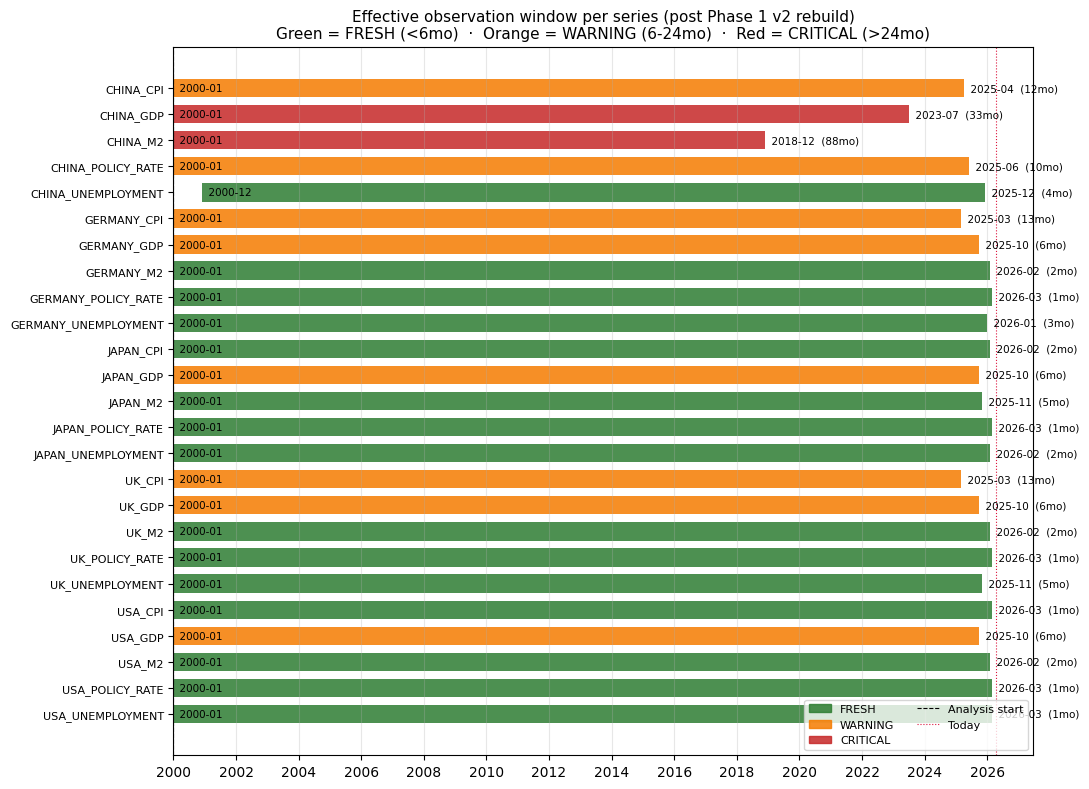

In [43]:
# Horizontal bar: effective observation window per series, coloured by freshness
fig, ax = plt.subplots(figsize=(11, 8))
sorted_rows = DIAGNOSTIC_V2.sort_values(['country', 'indicator']).reset_index(drop=True)
color_map = {'FRESH': '#2e7d32', 'WARNING': '#f57c00', 'CRITICAL': '#c62828', 'MISSING': '#9e9e9e'}

for i, r in sorted_rows.iterrows():
    if r['effective_end'] is None:
        continue
    eff_end = pd.Timestamp(r['effective_end'] + '-01')
    eff_start = pd.Timestamp(r['effective_start'] + '-01') if r.get('effective_start') else eff_end
    ax.barh(i, (eff_end - eff_start).days,
            left=mdates.date2num(eff_start), height=0.7,
            color=color_map[r['freshness']], alpha=0.85)
    ax.text(mdates.date2num(eff_start), i, f"  {r['effective_start']}",
            va='center', fontsize=7.5)
    ax.text(mdates.date2num(eff_end), i,
            f"  {r['effective_end']}  ({int(r['months_outdated'])}mo)",
            va='center', fontsize=7.5)

ax.set_yticks(range(len(sorted_rows)))
ax.set_yticklabels([f"{r['country']}_{r['indicator']}" for _, r in sorted_rows.iterrows()],
                   fontsize=8)
ax.invert_yaxis()
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='x', alpha=0.3)
ax.axvline(mdates.date2num(pd.Timestamp('2000-01-01')), color='black',
           linestyle='--', linewidth=0.8)
ax.axvline(mdates.date2num(pd.Timestamp.today()), color='crimson',
           linestyle=':', linewidth=0.8)

legend_handles = [plt.matplotlib.patches.Patch(color=c, alpha=0.85, label=l)
                  for l, c in color_map.items() if l != 'MISSING' or (DIAGNOSTIC_V2['freshness']=='MISSING').any()]
legend_handles += [plt.Line2D([0],[0], color='black', linestyle='--',
                              linewidth=0.8, label='Analysis start'),
                   plt.Line2D([0],[0], color='crimson', linestyle=':',
                              linewidth=0.8, label='Today')]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8, ncol=2)
ax.set_title('Effective observation window per series (post Phase 1 v2 rebuild)\n'
             'Green = FRESH (<6mo)  ·  Orange = WARNING (6-24mo)  ·  Red = CRITICAL (>24mo)',
             fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'data_collection_staleness_bar.png', dpi=120, bbox_inches='tight')
plt.show()

### 10.2 Cross-Country CPI Trends

Normalised to 100 at 2000-01 for visual comparison. The 2022 inflation surge is visible across all four main-analysis countries; Japan's preceding low-inflation regime is equally striking.

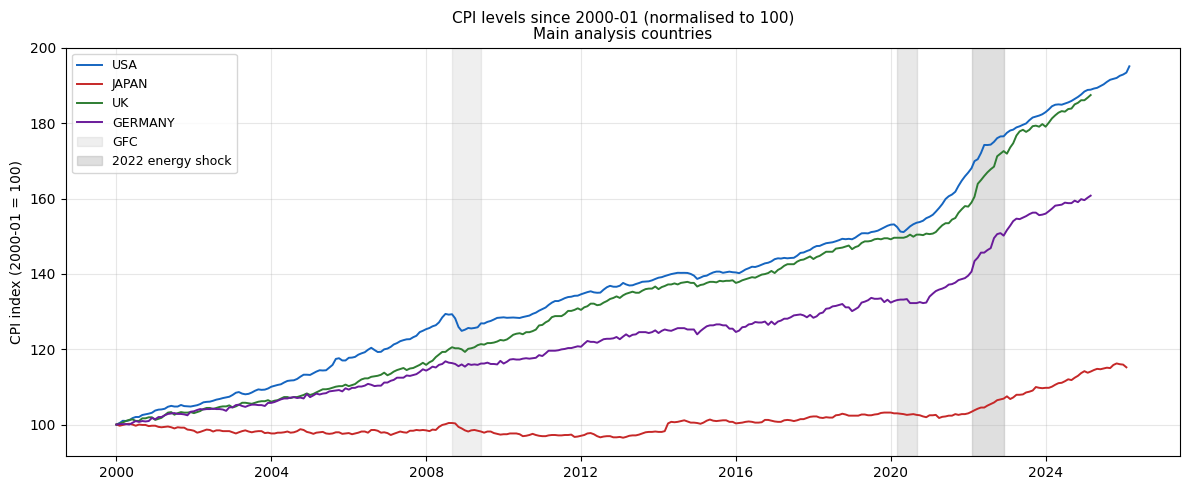

In [44]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'USA': '#1565c0', 'JAPAN': '#c62828', 'UK': '#2e7d32', 'GERMANY': '#6a1b9a'}

for country in ['USA', 'JAPAN', 'UK', 'GERMANY']:
    s, err = load_series(country, 'CPI')
    if s is None: continue
    s = s.dropna()
    s = s[s.index >= '2000-01-01']
    if s.empty: continue
    s_norm = 100 * s / s.iloc[0]
    ax.plot(s_norm.index, s_norm.values, label=country, color=colors[country], linewidth=1.4)

ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-01'),
           color='grey', alpha=0.12, label='GFC')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
           color='grey', alpha=0.18)
ax.axvspan(pd.Timestamp('2022-02-01'), pd.Timestamp('2022-12-01'),
           color='grey', alpha=0.25, label='2022 energy shock')
ax.set_title('CPI levels since 2000-01 (normalised to 100)\nMain analysis countries',
             fontsize=11)
ax.set_ylabel('CPI index (2000-01 = 100)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'data_collection_cpi_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 10.3 The Japan CPI Rescue

The plot below directly contrasts the v1 Japan CPI (FRED `JPNCPIALLMINMEI`, effective end 2021-06 with ten months of trailing NaN) against the v2 series (direct from the Japan Statistics Bureau, extending through the most recent observation). The 2022 inflation reversal — the empirical foundation of narrative N3 — is absent in v1 and present in v2.

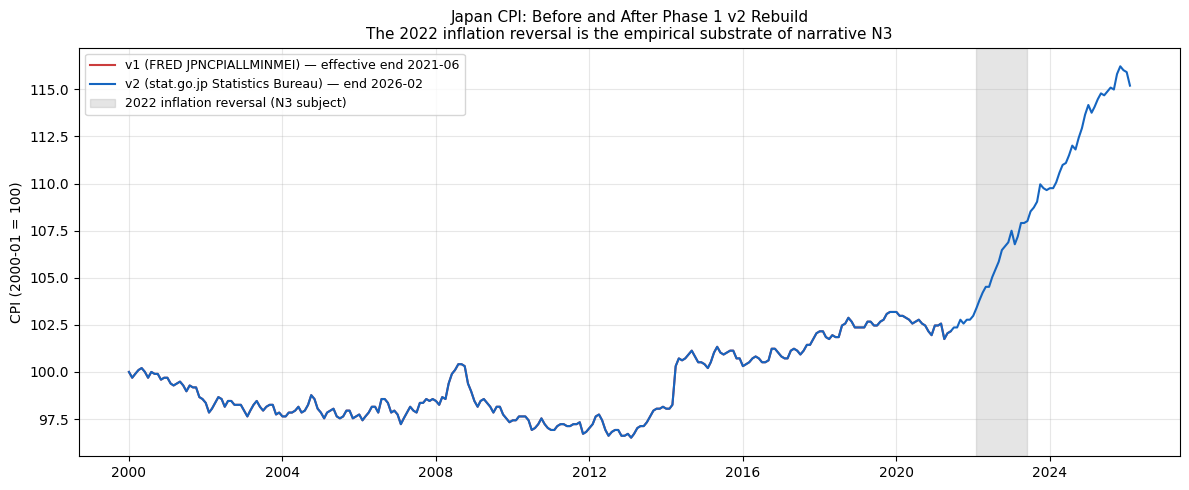

In [45]:
fig, ax = plt.subplots(figsize=(12, 5))

# v2 current
s_v2, _ = load_series('JAPAN', 'CPI')
s_v2 = s_v2.dropna()
s_v2 = s_v2[s_v2.index >= '2000-01-01']
s_v2_n = 100 * s_v2 / s_v2.iloc[0]

# v1 archive
v1_path = ARCHIVE_DIR / 'JAPAN_CPI.csv'
if v1_path.exists():
    df_v1 = pd.read_csv(v1_path, parse_dates=['date']).set_index('date')
    v1 = df_v1.iloc[:, 0].dropna()
    v1 = v1[v1.index >= '2000-01-01']
    v1_n = 100 * v1 / v1.iloc[0]
    ax.plot(v1_n.index, v1_n.values, color='#c62828', linewidth=1.5, alpha=0.9,
            label=f'v1 (FRED JPNCPIALLMINMEI) — effective end {v1.index.max().strftime("%Y-%m")}')

ax.plot(s_v2_n.index, s_v2_n.values, color='#1565c0', linewidth=1.5,
        label=f'v2 (stat.go.jp Statistics Bureau) — end {s_v2.index.max().strftime("%Y-%m")}')
ax.axvspan(pd.Timestamp('2022-02-01'), pd.Timestamp('2023-06-01'),
           color='grey', alpha=0.2, label='2022 inflation reversal (N3 subject)')

ax.set_title('Japan CPI: Before and After Phase 1 v2 Rebuild\n'
             'The 2022 inflation reversal is the empirical substrate of narrative N3',
             fontsize=11)
ax.set_ylabel('CPI (2000-01 = 100)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'data_collection_jpn_cpi_v1_vs_v2.png', dpi=120, bbox_inches='tight')
plt.show()

### 10.4 Narrative Readiness

In [46]:
def narrative_ready(countries, indicators, min_end='2023-01'):
    for c in countries:
        for ind in indicators:
            row = DIAGNOSTIC_V2[(DIAGNOSTIC_V2['country']==c) & (DIAGNOSTIC_V2['indicator']==ind)]
            if row.empty: return False
            eff_end = row['effective_end'].iloc[0]
            if eff_end is None or eff_end < min_end: return False
    return True

main = ['USA', 'JAPAN', 'UK', 'GERMANY']
narratives = pd.DataFrame([
    {'narrative': 'N1 — Phillips Curve',
     'required': 'CPI × Unemployment',
     'countries': ', '.join(main),
     'status': '✅ Ready' if narrative_ready(main, ['CPI', 'UNEMPLOYMENT']) else '⚠️ Partial'},
    {'narrative': 'N2 — Monetary Policy Lag',
     'required': 'CPI × Policy Rate',
     'countries': ', '.join(main),
     'status': '✅ Ready' if narrative_ready(main, ['CPI', 'POLICY_RATE']) else '⚠️ Partial'},
    {'narrative': "N3 — Japan's Uniqueness",
     'required': 'Japan CPI through 2022+',
     'countries': 'JAPAN',
     'status': '✅ Ready' if narrative_ready(['JAPAN'], ['CPI']) else '❌ Blocked'},
])
print("Narrative readiness assessment (post-rebuild):\n")
narratives

Narrative readiness assessment (post-rebuild):



,narrative,required,countries,status
0,N1 — Phillips Curve,CPI × Unemployment,"USA, JAPAN, UK, GERMANY",✅ Ready
1,N2 — Monetary Policy Lag,CPI × Policy Rate,"USA, JAPAN, UK, GERMANY",✅ Ready
2,N3 — Japan's Uniqueness,Japan CPI through 2022+,JAPAN,✅ Ready


## 11. Data Integrity and Residual Limitations

Four limitations deserve explicit documentation:

### 11.1 UK GDP — WARNING status
The v2 UK GDP series (`NGDPRSAXDCGBQ`) ends ~6 months ago, placing it in the WARNING tier. This reflects normal ONS publication cadence rather than a pipeline defect. Impact on analysis is negligible.

### 11.2 Unit heterogeneity in money supply
USA and Germany M2 remain in level form (`M2SL`); Japan and UK use YoY growth (`MABMM301...`). Phase 2 cleaning will harmonise all to YoY growth — theoretically preferable under the Quantity Theory of Money.

### 11.3 Germany M2 placeholder
`INDICATORS_FINAL['GERMANY']['M2'] = 'M2SL'` inherits USA's Series ID as a proxy. A Germany-specific broad-money scout is scheduled for Phase 2.

### 11.4 China supplementary treatment
China series (notably M2 at 2018-12, unemployment as annual only) are consistent with D-001's supplementary framing. They are excluded from the main VAR models.

### 11.5 Zero internal structural gaps
A positive finding: across all 25 series, no internal NaN run exceeds three months. The cleaning policy (linear interpolation for ≤3mo, exclusion for longer) is therefore not binding — single-month missings only.

---

## 12. Decision Log and Next Steps

### 12.1 Decision Log References

All non-trivial design decisions are recorded in `ProjectDriven.md`. The decisions directly relevant to this notebook:

| ID | Decision | Phase |
|---|---|---|
| D-001 | China as supplementary with documented caveats | 0 |
| D-002 | Analysis window 2000-01 to present | 0 |
| D-003 | FRED as primary data source | 0 |
| D-005 | Train 2000–2019 / Test 2020–present split | 0 |
| D-006 | Phase 1 v1 collection (FRED, nominal 100%) | 1 |
| D-008 | Strategy D — targeted multi-source rebuild | 2 |
| D-012 | Money supply harmonised to YoY growth in Phase 2 | 2 |
| D-013 | Phase 1 v2 strategic rebuild | 2 |
| D-014 | Japan Policy Rate override (call money vs 10yr yield) | 2 |
| D-015 | UK GDP override (real vs nominal) | 2 |

### 12.2 Next Steps — Phase 2 Preview

This notebook produces the dataset that Phase 2 (Data Cleaning and Alignment) consumes. Phase 2 will focus on:

1. **Frequency harmonisation** — quarterly GDP → monthly (method D-007, TBD)
2. **Unit harmonisation** — USA/Germany M2 → YoY growth (D-012)
3. **Common-period alignment** — trim to main-country intersection
4. **Single-NaN interpolation** — linear interpolation for the remaining monthly gaps

Outputs will populate `data/processed/` and feed directly into Phase 3 stationarity and structural-break testing.

---

## Appendix A — Artifacts Produced by This Notebook

After a successful end-to-end run:

```
data/
├── raw/
│   ├── {COUNTRY}_{INDICATOR}.csv         ← 25 series, final (v2) state
│   └── _archive_v1/{timestamp}/          ← v1 CSVs archived from this run
├── documentation/
│   └── phase1v2_rebuild_log.csv          ← full audit trail
outputs/
└── figures/
    ├── data_collection_staleness_bar.png
    ├── data_collection_cpi_comparison.png
    └── data_collection_jpn_cpi_v1_vs_v2.png
```

---

## Appendix B — References

- **Phillips, A. W.** (1958). *The Relation between Unemployment and the Rate of Change of Money Wage Rates in the United Kingdom, 1861–1957.* Economica.
- **Friedman, M.** (1956). *The Quantity Theory of Money — A Restatement.* Studies in the Quantity Theory of Money.
- **Taylor, J. B.** (1993). *Discretion versus Policy Rules in Practice.* Carnegie-Rochester Conference Series on Public Policy.
- **Fernald, J. G., Hsu, E., & Spiegel, M. M.** (2021). *Is China fudging its GDP figures? Evidence from trading partner data.* Journal of International Money and Finance.
- **Federal Reserve Bank of St. Louis** — FRED Economic Data. https://fred.stlouisfed.org/
- **Statistics Bureau of Japan (総務省統計局)** — Consumer Price Index. https://www.stat.go.jp/data/cpi/
- **World Bank** — SL.UEM.TOTL.ZS Unemployment Total. https://data.worldbank.org/
